# Hybrid Semantic QC Dashboard

This notebook helps you analyze multilingual semantic consistency for both Silver and Gold data.

It reads available CSV/JSON artifacts, summarizes quality flags, and plots similarity distributions.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 140)

In [2]:
BASE = Path.cwd()

PATHS = {
    'silver_cleaned_balanced_csv': BASE / 'artifacts/silver_shard_3_cleaned/silver_shard_3.corrected.cleaned.balanced.csv',
    'silver_hybrid_csv': BASE / 'artifacts/silver_shard_3_qc/silver_shard_3.hybrid.corrected.csv',
    'silver_hybrid_report': BASE / 'artifacts/silver_shard_3_qc/silver_shard_3.hybrid.report.json',
    'gold_input_merged_csv': BASE / 'artifacts/gold_shard_3_merge/gold_shard_3.corrected.merged.csv',
    'gold_hybrid_csv': BASE / 'artifacts/gold_shard_3_merge/gold_shard_3.hybrid.corrected.csv',
    'gold_hybrid_report': BASE / 'artifacts/gold_shard_3_merge/gold_shard_3.hybrid.report.json',
}

availability = pd.DataFrame(
    [{'artifact': k, 'exists': v.exists(), 'path': str(v)} for k, v in PATHS.items()]
)
availability

,artifact,exists,path
0,silver_cleaned_balanced_csv,True,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_cleaned\silver_shard_3.corrected.cleaned.balanced.csv
1,silver_hybrid_csv,False,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_qc\silver_shard_3.hybrid.corrected.csv
2,silver_hybrid_report,False,c:\Users\RPC\Desktop\Traduction\artifacts\silver_shard_3_qc\silver_shard_3.hybrid.report.json
3,gold_input_merged_csv,True,c:\Users\RPC\Desktop\Traduction\artifacts\gold_shard_3_merge\gold_shard_3.corrected.merged.csv
4,gold_hybrid_csv,True,c:\Users\RPC\Desktop\Traduction\artifacts\gold_shard_3_merge\gold_shard_3.hybrid.corrected.csv
5,gold_hybrid_report,True,c:\Users\RPC\Desktop\Traduction\artifacts\gold_shard_3_merge\gold_shard_3.hybrid.report.json


In [3]:
def load_csv_safe(path: Path):
    if not path.exists():
        return None
    return pd.read_csv(path, encoding='utf-8-sig', dtype=object)


def load_json_safe(path: Path):
    if not path.exists():
        return None
    with path.open('r', encoding='utf-8') as fp:
        return json.load(fp)

In [4]:
dataframes = {
    'silver_cleaned_balanced': load_csv_safe(PATHS['silver_cleaned_balanced_csv']),
    'silver_hybrid': load_csv_safe(PATHS['silver_hybrid_csv']),
    'gold_input_merged': load_csv_safe(PATHS['gold_input_merged_csv']),
    'gold_hybrid': load_csv_safe(PATHS['gold_hybrid_csv']),
}

reports = {
    'silver_hybrid_report': load_json_safe(PATHS['silver_hybrid_report']),
    'gold_hybrid_report': load_json_safe(PATHS['gold_hybrid_report']),
}

def summarize_df(name, df):
    if df is None:
        return {'dataset': name, 'loaded': False}

    row = {
        'dataset': name,
        'loaded': True,
        'rows': int(len(df)),
        'has_status': 'status' in df.columns,
        'has_consistency_flag': 'consistency_flag' in df.columns,
        'has_similarity_score': 'similarity_score' in df.columns,
    }

    if 'status' in df.columns:
        counts = df['status'].fillna('NA').value_counts().to_dict()
        row['status_counts'] = counts

    if 'consistency_flag' in df.columns:
        counts = df['consistency_flag'].fillna('NA').value_counts().to_dict()
        row['consistency_flag_counts'] = counts

    if 'similarity_score' in df.columns:
        sim = pd.to_numeric(df['similarity_score'], errors='coerce')
        row['avg_similarity'] = float(sim.mean()) if sim.notna().any() else None

    return row

summary_df = pd.DataFrame([summarize_df(name, df) for name, df in dataframes.items()])
summary_df

,dataset,loaded,rows,has_status,has_consistency_flag,has_similarity_score,status_counts,consistency_flag_counts,avg_similarity
0,silver_cleaned_balanced,True,9005.0,True,False,False,"{'CLEAN': 8993, 'FLAGGED': 12}",NaN,NaN
1,silver_hybrid,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gold_input_merged,True,1000.0,True,False,False,"{'VALIDATED': 500, 'GENERATED': 373, 'PARTIALLY VALIDATED': 127}",NaN,NaN
3,gold_hybrid,True,1000.0,True,True,True,"{'VALIDATED': 500, 'GENERATED': 373, 'PARTIALLY VALIDATED': 127}","{'CORRECTED': 728, 'CONSISTENT': 270, 'SUSPICIOUS': 2}",0.372708


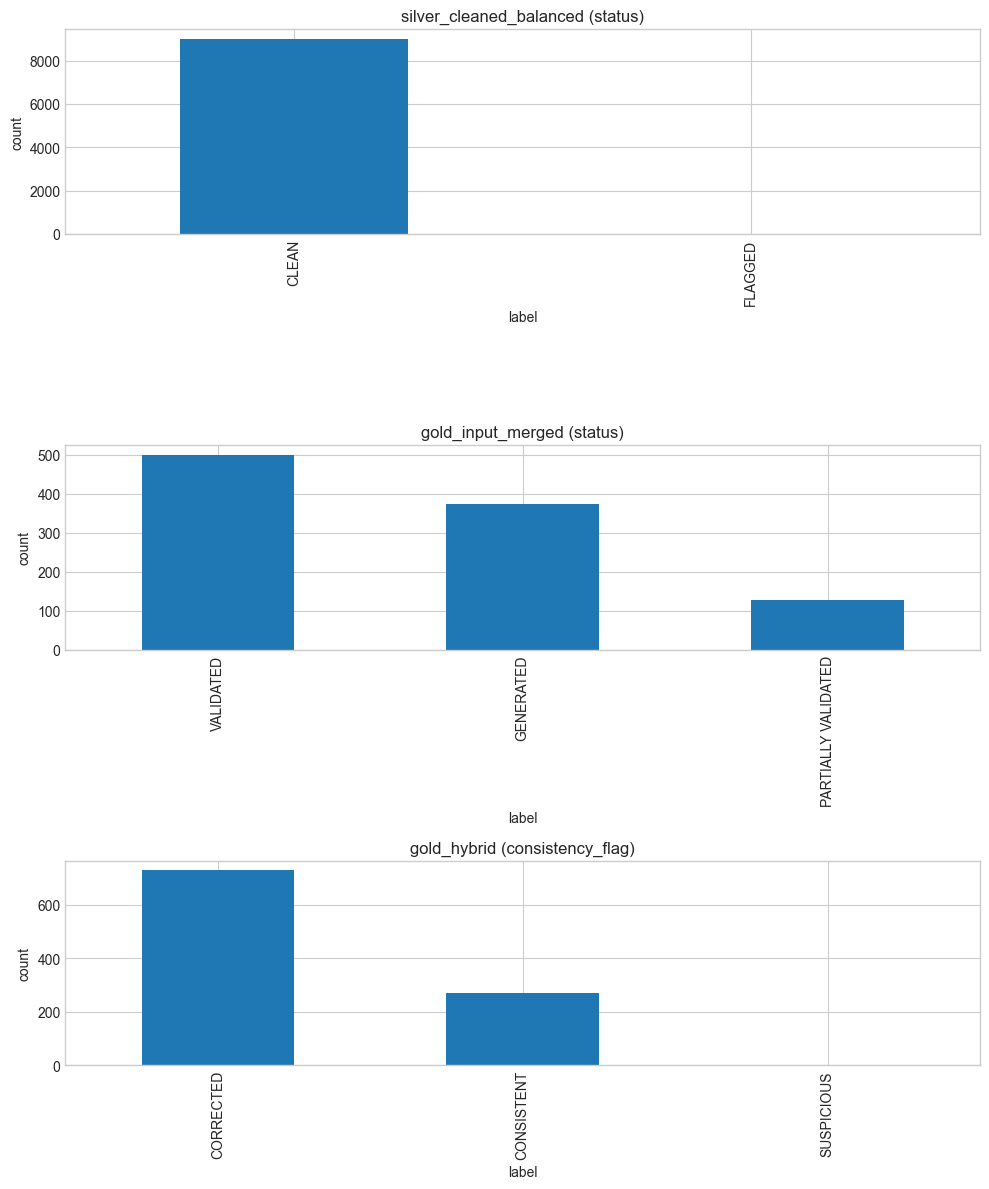

In [5]:
plot_items = []
for name, df in dataframes.items():
    if df is None:
        continue

    if 'consistency_flag' in df.columns:
        counts = df['consistency_flag'].fillna('NA').value_counts()
        plot_items.append((name + ' (consistency_flag)', counts))
    elif 'status' in df.columns:
        counts = df['status'].fillna('NA').value_counts()
        plot_items.append((name + ' (status)', counts))

if plot_items:
    fig, axes = plt.subplots(len(plot_items), 1, figsize=(10, 4 * len(plot_items)))
    if len(plot_items) == 1:
        axes = [axes]

    for ax, (title, counts) in zip(axes, plot_items):
        counts.plot(kind='bar', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('label')
        ax.set_ylabel('count')

    plt.tight_layout()
    plt.show()
else:
    print('No status/consistency columns found to plot.')

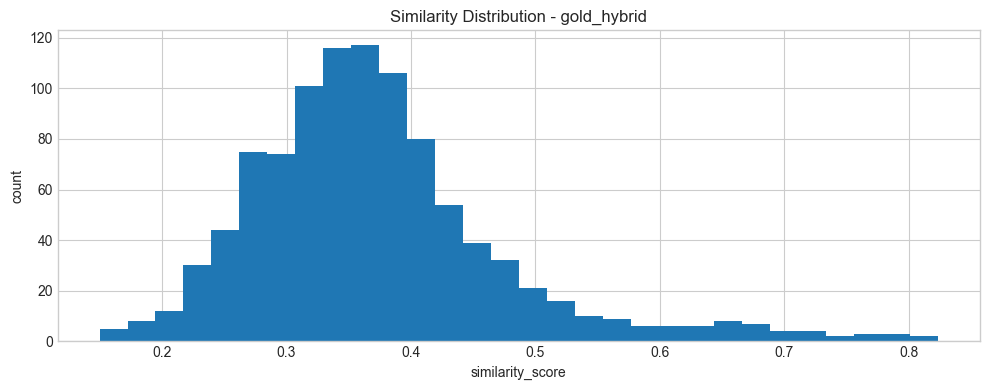

In [6]:
sim_plots = []
for name, df in dataframes.items():
    if df is None or 'similarity_score' not in df.columns:
        continue
    sim = pd.to_numeric(df['similarity_score'], errors='coerce').dropna()
    if not sim.empty:
        sim_plots.append((name, sim))

if sim_plots:
    fig, axes = plt.subplots(len(sim_plots), 1, figsize=(10, 4 * len(sim_plots)))
    if len(sim_plots) == 1:
        axes = [axes]

    for ax, (name, sim) in zip(axes, sim_plots):
        ax.hist(sim.values, bins=30)
        ax.set_title(f'Similarity Distribution - {name}')
        ax.set_xlabel('similarity_score')
        ax.set_ylabel('count')

    plt.tight_layout()
    plt.show()
else:
    print('No similarity_score column found yet. Run hybrid_semantic_consistency.py first.')

In [7]:
report_rows = []
wanted_keys = [
    'total_rows',
    'consistent_rows',
    'suspicious_rows',
    'corrected_rows',
    'average_similarity',
    'llm_calls',
    'estimated_cost_usd',
]

for report_name, report_data in reports.items():
    if report_data is None:
        report_rows.append({'report': report_name, 'loaded': False})
        continue

    row = {'report': report_name, 'loaded': True}
    for key in wanted_keys:
        row[key] = report_data.get(key)
    report_rows.append(row)

pd.DataFrame(report_rows)

,report,loaded,total_rows,consistent_rows,suspicious_rows,corrected_rows,average_similarity,llm_calls,estimated_cost_usd
0,silver_hybrid_report,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gold_hybrid_report,True,1000.0,270.0,2.0,728.0,0.372708,998.0,0.657708


## Run Hybrid QC for Silver and Gold

Before running, set OPENAI_API_KEY in your shell.

Example commands:

```bash
py -3 hybrid_semantic_consistency.py --input artifacts/silver_shard_3_cleaned/silver_shard_3.corrected.cleaned.balanced.csv --output artifacts/silver_shard_3_qc/silver_shard_3.hybrid.corrected.csv --report artifacts/silver_shard_3_qc/silver_shard_3.hybrid.report.json --threshold 0.80 --model gpt-4.1-mini --workers 6

py -3 hybrid_semantic_consistency.py --input artifacts/gold_shard_3_merge/gold_shard_3.corrected.merged.csv --output artifacts/gold_shard_3_merge/gold_shard_3.hybrid.corrected.csv --report artifacts/gold_shard_3_merge/gold_shard_3.hybrid.report.json --threshold 0.80 --model gpt-4.1-mini --workers 6
```